In [89]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy.stats import linregress

In [90]:
deepcsa_run_dir = '/data/bbg/nobackup2/prominent/duplex_seq_tests/error_rate/cord_blood/bbg/deepCSA/2026-06-26_deepUMIcaller_and_dupcaller_4_paper'

## Indels comparisons

### Indel mutation density

In [91]:
mutation_densities = pd.read_table(f"{deepcsa_run_dir}/mutdensity/all_mutdensities.tsv")
mutation_densities["Caller"] = mutation_densities["SAMPLE_ID"].apply(lambda x: "DupCaller" if "dupcaller" in x.lower() else "deepUMIcaller")
mutation_densities.head()

,SAMPLE_ID,GENE,REGIONS,MUTTYPES,DEPTH,N_MUTS,N_MUTATED,MUTDENSITY_MB,MUTDENSITY_MB_ADJUSTED,MUTREADSDENSITY_MB,MUTREADSDENSITY_MB_ADJUSTED,Caller
0,MethodIdt_CallerDeepumicaller,ALL_GENES,non_protein_affecting,all_types,5180177525,81.0,85.0,0.015637,0.017651,0.016409,0.018523,deepUMIcaller
1,MethodIdt_CallerDeepumicaller,ALL_GENES,non_protein_affecting,SNV,5180177525,75.0,79.0,0.014478,0.016344,0.015250,0.017215,deepUMIcaller
2,MethodIdt_CallerDeepumicaller,ALL_GENES,non_protein_affecting,DELETION-INSERTION,5180177525,6.0,6.0,0.001158,0.001307,0.001158,0.001307,deepUMIcaller
3,MethodIdt_CallerDeepumicaller,ALL_GENES,non_protein_affecting,DELETION-INSERTION-SNV,5180177525,81.0,85.0,0.015637,0.017651,0.016409,0.018523,deepUMIcaller
4,MethodIdt_CallerDeepumicaller,ACVR2A,non_protein_affecting,all_types,14724295,0.0,0.0,0.000000,0.000000,0.000000,0.000000,deepUMIcaller


In [92]:
mutation_type = 'indels'
samples_of_interest = ["SC003_B1_1_H_2", "SC002_B1_1_H_2", "SC001_B1_1_H_2",
                       "SC003_B1_1_H_2_dupcaller", "SC002_B1_1_H_2_dupcaller", "SC001_B1_1_H_2_dupcaller"
                       ]

upd_samples_of_interest = [
    "SC001_B1_1_H_2", "SC001_B1_1_H_2_DC",
    "SC002_B1_1_H_2", "SC002_B1_1_H_2_DC", 
    "SC003_B1_1_H_2", "SC003_B1_1_H_2_DC",
    ]


mutation_densities_of_interest = mutation_densities[
    (mutation_densities["MUTTYPES"] == 'DELETION-INSERTION')
    # (mutation_densities["MUTTYPES"] == 'SNV')
    & (mutation_densities["SAMPLE_ID"].isin(samples_of_interest))
    & (mutation_densities["REGIONS"].isin(["all"]))
    & (mutation_densities["GENE"].isin(["ALL_GENES"]))
].copy()
mutation_densities_of_interest["SAMPLE"] = mutation_densities_of_interest["SAMPLE_ID"].apply(lambda x: x.replace("_dupcaller", ""))
mutation_densities_of_interest = mutation_densities_of_interest.sort_values(by=["SAMPLE", "Caller"])
mutation_densities_of_interest


,SAMPLE_ID,GENE,REGIONS,MUTTYPES,DEPTH,N_MUTS,N_MUTATED,MUTDENSITY_MB,MUTDENSITY_MB_ADJUSTED,MUTREADSDENSITY_MB,MUTREADSDENSITY_MB_ADJUSTED,Caller,SAMPLE
10386,SC001_B1_1_H_2_dupcaller,ALL_GENES,all,DELETION-INSERTION,2211812690,13.0,13.0,0.005878,0.005878,0.005878,0.005878,DupCaller,SC001_B1_1_H_2
69346,SC001_B1_1_H_2,ALL_GENES,all,DELETION-INSERTION,2145974912,10.0,10.0,0.004660,0.004660,0.004660,0.004660,deepUMIcaller,SC001_B1_1_H_2
59978,SC002_B1_1_H_2_dupcaller,ALL_GENES,all,DELETION-INSERTION,2869620914,7.0,7.0,0.002439,0.002439,0.002439,0.002439,DupCaller,SC002_B1_1_H_2
37898,SC002_B1_1_H_2,ALL_GENES,all,DELETION-INSERTION,2780980595,6.0,6.0,0.002158,0.002158,0.002158,0.002158,deepUMIcaller,SC002_B1_1_H_2
41538,SC003_B1_1_H_2_dupcaller,ALL_GENES,all,DELETION-INSERTION,3955477901,9.0,25.0,0.002275,0.002275,0.006320,0.006320,DupCaller,SC003_B1_1_H_2
66482,SC003_B1_1_H_2,ALL_GENES,all,DELETION-INSERTION,3829251123,6.0,6.0,0.001567,0.001567,0.001567,0.001567,deepUMIcaller,SC003_B1_1_H_2


In [93]:
mutation_densities_of_interest.sort_values(by=["SAMPLE", "Caller"])[["DEPTH", "N_MUTS", "MUTDENSITY_MB"]] #, "SAMPLE", "Caller"]]

,DEPTH,N_MUTS,MUTDENSITY_MB
10386,2211812690,13.0,0.005878
69346,2145974912,10.0,0.004660
59978,2869620914,7.0,0.002439
37898,2780980595,6.0,0.002158
41538,3955477901,9.0,0.002275
66482,3829251123,6.0,0.001567


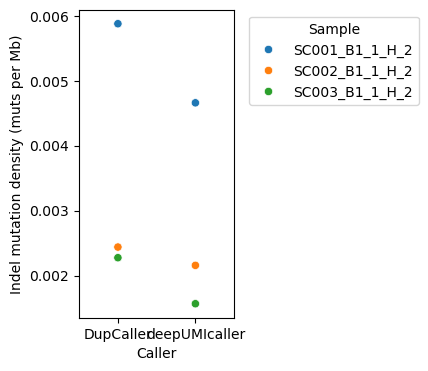

In [ ]:
plt.figure(figsize=(2, 4))
sns.scatterplot(data=mutation_densities_of_interest,
                x="Caller", y="MUTDENSITY_MB",
                hue="SAMPLE")
plt.xlim(-0.5, 1.5)
plt.xlabel("Caller")
plt.ylabel("Indel mutation density (muts per Mb)")
plt.legend(title="Sample", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig("../plots/indel_mutation_density_comparison.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [98]:

# --- Error rate plot --------------------------------------------------------
from zipfile import Path

from matplotlib.patches import Patch
from matplotlib.ticker import ScalarFormatter


def plot_error_rate(mutrate: pd.DataFrame, samples: list, outdir: Path, protocol_order: list, ylim: float = 1e-8):
    """
    Plot error rate for all samples (deepUMIcaller + DupCaller).
    Bars whose protocol is 'corrected' or 'uncorrected' are drawn as outlines only (no fill).
    ALT samples are separated from the rest by a broken x-axis gap.
    """
    UNFILLED_PROTOCOLS = {'corrected', 'uncorrected'}
    ALT_GAP = 0.8  # extra x-space inserted before the first ALT bar

    colors = dict(zip(protocol_order, sns.color_palette('muted')))
    colors["deepUMIcaller"] = colors["DupCaller"]

    sample_rows = {}
    for s in samples:
        match = mutrate[mutrate['sample'] == s]
        if not match.empty:
            sample_rows[s] = match.iloc[0]

    # --- Compute custom x positions (gap before first ALT bar) -------------
    x_positions = []
    gap_added = False
    alt_start_idx = None
    x = 0
    for idx, sample in enumerate(samples):
        row = sample_rows.get(sample)
        if row is not None and row['protocol'] == 'ALT' and not gap_added:
            x += ALT_GAP
            gap_added = True
            alt_start_idx = idx
        x_positions.append(x)
        x += 1

    x_min = -0.5
    x_max = x_positions[-1] + 0.5

    fig, ax = plt.subplots(figsize=(4.5, 2.5))

    for x_pos, sample in zip(x_positions, samples):
        row = sample_rows.get(sample)
        if row is None:
            continue
        color       = colors.get(row['protocol'], 'gray')
        is_dc       = '_DC' in sample  # Add hatch for DupCaller samples
        is_unfilled = False
        yerr_lo     = row['mutrate_observed'] - row['mutrate_CI_low']
        yerr_hi     = row['mutrate_CI_high']  - row['mutrate_observed']

        ax.bar(
            x_pos, row['mutrate_observed'],
            color     = 'none' if is_unfilled else color,
            hatch     = '//' if (is_dc and not is_unfilled) else '',
            edgecolor = color if is_unfilled else ('white' if is_dc else color),
            linewidth = 1.5 if is_unfilled else 0.5,
            width     = 0.7,
        )
        ax.errorbar(
            x_pos, row['mutrate_observed'],
            yerr=[[yerr_lo], [yerr_hi]],
            fmt='none', ecolor='black', capsize=3, lw=0.8,
        )

    # ax.axhline(y=2e-8, color='red', linestyle='--',
    #            label='Expected mutations', linewidth=0.5)
    # ax.axhline(y=1e-8, color='red', linestyle='--', linewidth=0.5)

    # y-axis
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(fmt)

    sns.despine(ax=ax, top=True, right=True)
    ax.set_xlabel('')
    ax.set_ylabel('Indels per bp')
    ax.set_title('Cord blood DNA')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(samples, rotation=45, ha='right', fontsize=7)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, ylim)

    # --- Broken x-axis spine -----------------------------------------------
    if alt_start_idx is not None:
        ax.spines['bottom'].set_visible(False) # Remove line
        total_width   = x_max - x_min 
        gap_start_ax  = (x_positions[alt_start_idx - 1] + 0.5 - x_min) / total_width
        gap_end_ax    = (x_positions[alt_start_idx]     - 0.5 - x_min) / total_width
        spine_lw = 0.8
        ax.add_line(plt.Line2D([0, gap_start_ax], [0, 0], # Add line to first part
                               transform=ax.transAxes, color='black',
                               linewidth=spine_lw, clip_on=False))
        ax.add_line(plt.Line2D([gap_end_ax, 1], [0, 0], # Add line to second part
                               transform=ax.transAxes, color='black',
                               linewidth=spine_lw, clip_on=False))

    # --- Legend ------------------------------------------------------------
    handles = []
    for p in protocol_order:
        if p not in colors or p == 'others':
            continue
        if p in UNFILLED_PROTOCOLS:
            continue
        else:
            handles.append(Patch(facecolor=colors[p], label=p))
    handles.append(Patch(facecolor=colors['DupCaller'], hatch='///', edgecolor='white',
                         label='DupCaller'))
    # handles.append(Patch(facecolor='none', edgecolor='gray', linewidth=1.5,
    #                      label='DupCaller report'))
    # handles.append(plt.Line2D([0], [0], color='red', linestyle='--',
    #                            linewidth=0.8, label='Expected mutations'))
    ax.legend(handles=handles, title='', frameon=False,
              bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=7)

    plt.subplots_adjust(bottom=0.35, right=0.75)
    plt.savefig(outdir,
                bbox_inches='tight', dpi=300)
    plt.show()


In [96]:
import pandas as pd
from scipy.stats import poisson


mutation_densities_of_interest_for_plot = mutation_densities_of_interest.copy()
mutation_densities_of_interest_for_plot["SAMPLE_ID"] = mutation_densities_of_interest_for_plot["SAMPLE_ID"].apply(lambda x: x.replace("_dupcaller", "_DC"))
mutation_densities_of_interest_for_plot = mutation_densities_of_interest_for_plot.rename(columns={"SAMPLE_ID": "sample",
                                                        "Caller": "protocol"
                                                        })

alpha = 0.05

lower, upper = poisson.interval(
    1 - alpha,
    mutation_densities_of_interest_for_plot["N_MUTS"]
)

mutation_densities_of_interest_for_plot["mutrate_observed"] = mutation_densities_of_interest_for_plot["N_MUTS"] / mutation_densities_of_interest_for_plot["DEPTH"]
mutation_densities_of_interest_for_plot["mutrate_CI_low"] = lower / mutation_densities_of_interest_for_plot["DEPTH"]
mutation_densities_of_interest_for_plot["mutrate_CI_high"] = upper / mutation_densities_of_interest_for_plot["DEPTH"]

mutation_densities_of_interest_for_plot

,sample,GENE,REGIONS,MUTTYPES,DEPTH,N_MUTS,N_MUTATED,MUTDENSITY_MB,MUTDENSITY_MB_ADJUSTED,MUTREADSDENSITY_MB,MUTREADSDENSITY_MB_ADJUSTED,protocol,SAMPLE,mutrate_observed,mutrate_CI_low,mutrate_CI_high
10386,SC001_B1_1_H_2_DC,ALL_GENES,all,DELETION-INSERTION,2211812690,13.0,13.0,0.005878,0.005878,0.005878,0.005878,DupCaller,SC001_B1_1_H_2,5.877532e-09,2.712707e-09,9.494475e-09
69346,SC001_B1_1_H_2,ALL_GENES,all,DELETION-INSERTION,2145974912,10.0,10.0,0.004660,0.004660,0.004660,0.004660,deepUMIcaller,SC001_B1_1_H_2,4.659887e-09,1.863955e-09,7.921807e-09
59978,SC002_B1_1_H_2_DC,ALL_GENES,all,DELETION-INSERTION,2869620914,7.0,7.0,0.002439,0.002439,0.002439,0.002439,DupCaller,SC002_B1_1_H_2,2.439347e-09,6.969562e-10,4.530215e-09
37898,SC002_B1_1_H_2,ALL_GENES,all,DELETION-INSERTION,2780980595,6.0,6.0,0.002158,0.002158,0.002158,0.002158,deepUMIcaller,SC002_B1_1_H_2,2.157512e-09,7.191708e-10,3.955439e-09
41538,SC003_B1_1_H_2_DC,ALL_GENES,all,DELETION-INSERTION,3955477901,9.0,25.0,0.002275,0.002275,0.006320,0.006320,DupCaller,SC003_B1_1_H_2,2.275326e-09,1.011256e-09,3.792209e-09
66482,SC003_B1_1_H_2,ALL_GENES,all,DELETION-INSERTION,3829251123,6.0,6.0,0.001567,0.001567,0.001567,0.001567,deepUMIcaller,SC003_B1_1_H_2,1.566886e-09,5.222953e-10,2.872624e-09


In [100]:
mutation_densities_of_interest_for_plot[["sample", "protocol", "N_MUTS","mutrate_observed", "mutrate_CI_low", "mutrate_CI_high"]]

,sample,protocol,N_MUTS,mutrate_observed,mutrate_CI_low,mutrate_CI_high
10386,SC001_B1_1_H_2_DC,DupCaller,13.0,5.877532e-09,2.712707e-09,9.494475e-09
69346,SC001_B1_1_H_2,deepUMIcaller,10.0,4.659887e-09,1.863955e-09,7.921807e-09
59978,SC002_B1_1_H_2_DC,DupCaller,7.0,2.439347e-09,6.969562e-10,4.530215e-09
37898,SC002_B1_1_H_2,deepUMIcaller,6.0,2.157512e-09,7.191708e-10,3.955439e-09
41538,SC003_B1_1_H_2_DC,DupCaller,9.0,2.275326e-09,1.011256e-09,3.792209e-09
66482,SC003_B1_1_H_2,deepUMIcaller,6.0,1.566886e-09,5.222953e-10,2.872624e-09


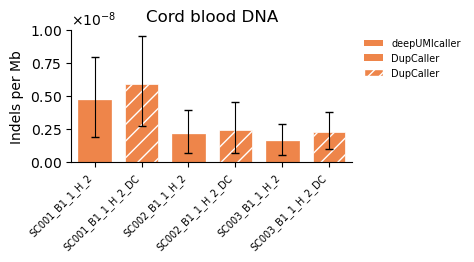

In [ ]:
OUTDIR = '../plots/20260226_mutrate_indels.pdf'
plot_error_rate(mutrate=mutation_densities_of_interest_for_plot, samples=upd_samples_of_interest,
                outdir=OUTDIR,
                protocol_order=["deepUMIcaller", "DupCaller"])